In [1]:
import numpy as np
import tifffile
from ganrectf.utils import angles, nor_tomo, nor_phase
from ganrectf.ganrec import GANtomo, GANphase

2026-04-16 16:32:34.441850: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
prj = tifffile.imread('./test_data/tooth.tiff')
nang, px = prj.shape
ang = angles(nang)
# prj = nor_tomo(prj)


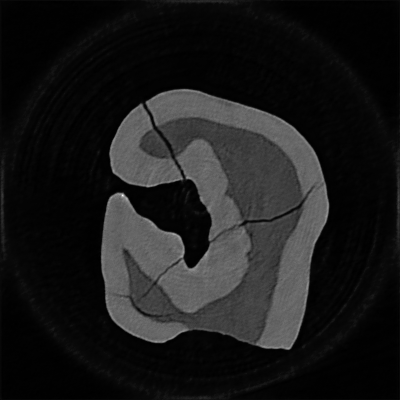
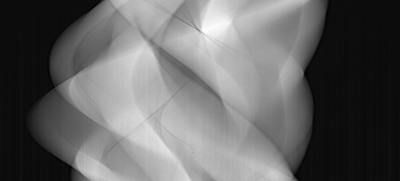
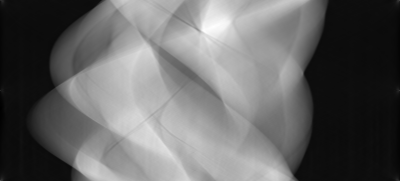

In [3]:
gan = GANtomo(prj, ang,
              iter_num=2000,
              l1_ratio=100,
              g_learning_rate=1e-4,
              recon_monitor=True)
recon = gan.recon()


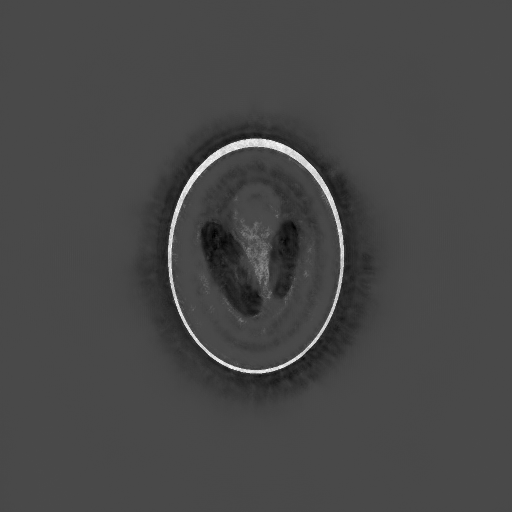
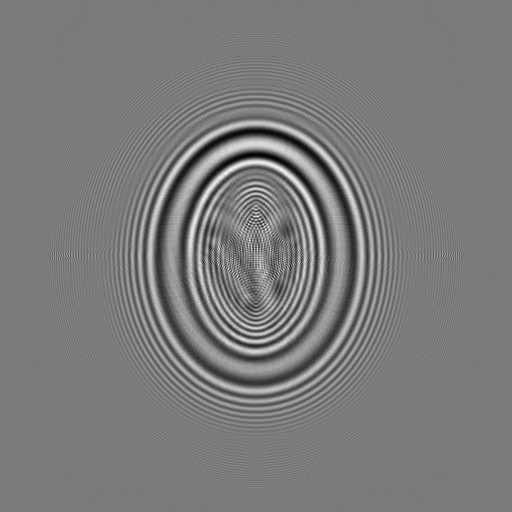
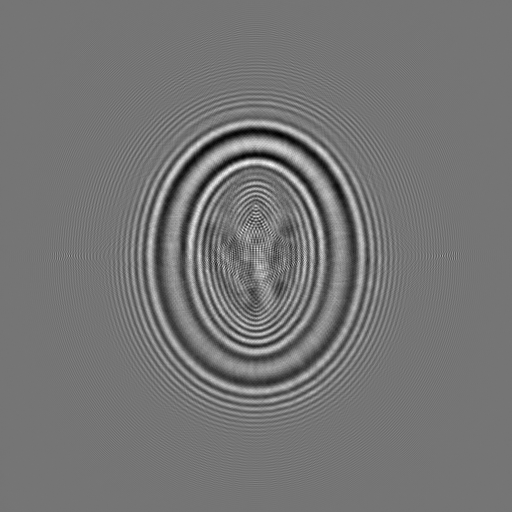

In [4]:
energy = 10       # keV
z = 0.5           # propagation distance (m)
pv = 5e-7         # pixel size (m)
abs_ratio = 0.5

fname_data = './test_data/hologram_shepp.tiff'
data = tifffile.imread(fname_data)

gan_phase = GANphase(data, energy, z, pv,
                     abs_ratio=abs_ratio,
                     iter_num=2000,
                     g_learning_rate=1e-4,
                     recon_monitor=True)
phase = gan_phase.recon()


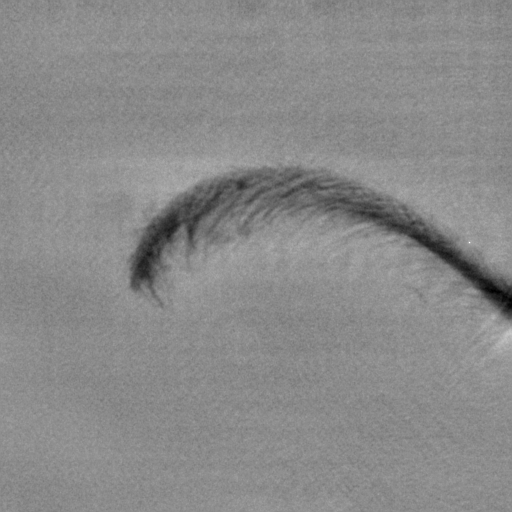
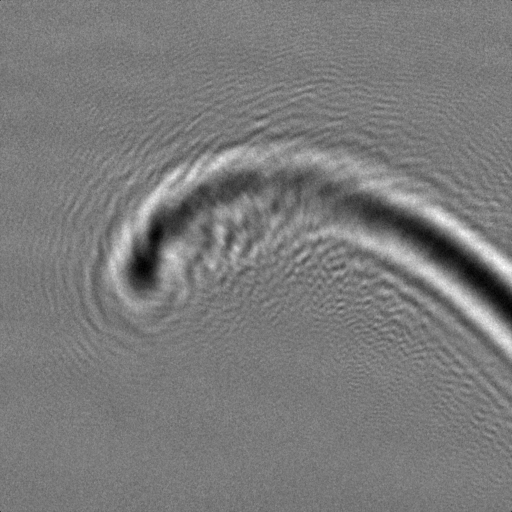
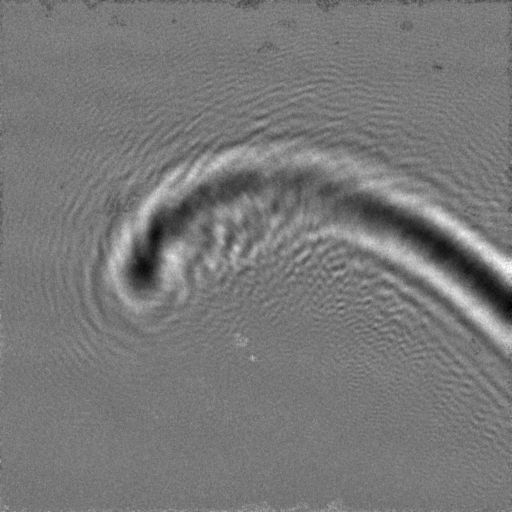

In [3]:
energy = 11
z = 7.8880960e-2
pv = 1.04735263e-7
abs_ratio = 0.06
iter_num = 2000
g_learning_rate = 1e-3
d_learning_rate = 1e-6
fname_data = './test_data/hologram_spider_hair.tiff'
data = tifffile.imread(fname_data)

gan_phase = GANphase(data, energy, z, pv,
                     abs_ratio=abs_ratio,
                     iter_num=iter_num,
                     g_learning_rate=g_learning_rate,
                     d_learning_rate=d_learning_rate,
                     recon_monitor=True)
phase = gan_phase.recon()